In [160]:
# importing Libraries First

In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
from sklearn.model_selection import cross_val_score

In [162]:
df = pd.read_csv(r"C:\Users\gaura\OneDrive\Desktop\Habit Tracker Project\habit_tracker_dataset.csv")

In [163]:
df.shape

(5000, 31)

In [164]:
pd.set_option("display.max_columns",50)

In [165]:
df.head()

,User_ID,Age,Gender,Occupation,Personality_Type,Working_Hours_Per_Day,Habit_Name,Habit_Category,Habit_Difficulty,Habit_Importance,Reminder_Set,Is_Group_Habit,Date,Day_of_Week,Is_Weekend,Total_Days_Tracked,Total_Days_Completed,Current_Streak,Longest_Streak,Completion_Rate_Last_7_Days,Completion_Rate_Last_30_Days,Skipped_Yesterday,Motivation_Level,Stress_Level,Mood_Score,Energy_Level,Sleep_Hours,Screen_Time_Hours,Social_Interaction_Level,Weather_Condition,Habit_Completed_Today
0,1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-01,Monday,0,1,1,1,1,1.000000,1.000000,0,8,7.0,4.0,5,4.5,4.8,5,Rainy,1
1,1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-02,Tuesday,0,2,1,0,1,0.500000,0.500000,1,5,8.0,6.0,8,5.1,3.1,5,Rainy,0
2,1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-03,Wednesday,0,3,1,0,1,0.333333,0.333333,1,5,6.0,7.0,6,4.1,5.1,3,Sunny,0
3,1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-04,Thursday,0,4,1,0,1,0.250000,0.250000,1,8,3.0,9.0,7,6.3,2.1,9,Sunny,0
4,1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-05,Friday,0,5,2,1,1,0.400000,0.400000,0,5,9.0,4.0,7,5.2,3.4,7,Hot,1


In [166]:
df.tail()

,User_ID,Age,Gender,Occupation,Personality_Type,Working_Hours_Per_Day,Habit_Name,Habit_Category,Habit_Difficulty,Habit_Importance,Reminder_Set,Is_Group_Habit,Date,Day_of_Week,Is_Weekend,Total_Days_Tracked,Total_Days_Completed,Current_Streak,Longest_Streak,Completion_Rate_Last_7_Days,Completion_Rate_Last_30_Days,Skipped_Yesterday,Motivation_Level,Stress_Level,Mood_Score,Energy_Level,Sleep_Hours,Screen_Time_Hours,Social_Interaction_Level,Weather_Condition,Habit_Completed_Today
4995,100,39,Male,Corporate,Introvert,4,Deep Work,Productivity,2,4,1,0,2024-01-06,Saturday,1,6,2,0,2,0.333333,0.333333,1,6,NaN,4.0,5,5.8,7.7,4,Sunny,0
4996,100,39,Male,Corporate,Introvert,4,Deep Work,Productivity,2,4,1,0,2024-01-07,Sunday,1,7,3,1,2,0.428571,0.428571,0,5,4.0,9.0,9,5.6,7.0,2,Rainy,1
4997,100,39,Male,Corporate,Introvert,4,Deep Work,Productivity,2,4,1,0,2024-01-08,Monday,0,8,4,2,2,0.500000,0.500000,0,8,1.0,3.0,5,7.2,2.8,2,Sunny,1
4998,100,39,Male,Corporate,Introvert,4,Deep Work,Productivity,2,4,1,0,2024-01-09,Tuesday,0,9,4,0,2,0.444444,0.444444,1,8,8.0,6.0,7,5.5,3.4,6,Cloudy,0
4999,100,39,Male,Corporate,Introvert,4,Deep Work,Productivity,2,4,1,0,2024-01-10,Wednesday,0,10,4,0,2,0.400000,0.400000,1,7,7.0,6.0,5,NaN,3.3,8,Rainy,0


In [167]:
df.isna().sum()

User_ID                           0
Age                               0
Gender                            0
Occupation                        0
Personality_Type                  0
Working_Hours_Per_Day             0
Habit_Name                        0
Habit_Category                    0
Habit_Difficulty                  0
Habit_Importance                  0
Reminder_Set                      0
Is_Group_Habit                    0
Date                              0
Day_of_Week                       0
Is_Weekend                        0
Total_Days_Tracked                0
Total_Days_Completed              0
Current_Streak                    0
Longest_Streak                    0
Completion_Rate_Last_7_Days       0
Completion_Rate_Last_30_Days      0
Skipped_Yesterday                 0
Motivation_Level                  0
Stress_Level                    250
Mood_Score                      250
Energy_Level                      0
Sleep_Hours                     250
Screen_Time_Hours           

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       5000 non-null   int64  
 1   Age                           5000 non-null   int64  
 2   Gender                        5000 non-null   object 
 3   Occupation                    5000 non-null   object 
 4   Personality_Type              5000 non-null   object 
 5   Working_Hours_Per_Day         5000 non-null   int64  
 6   Habit_Name                    5000 non-null   object 
 7   Habit_Category                5000 non-null   object 
 8   Habit_Difficulty              5000 non-null   int64  
 9   Habit_Importance              5000 non-null   int64  
 10  Reminder_Set                  5000 non-null   int64  
 11  Is_Group_Habit                5000 non-null   int64  
 12  Date                          5000 non-null   object 
 13  Day

In [169]:
df['Habit_Completed_Today'].value_counts(normalize= True)

Habit_Completed_Today
0    0.6012
1    0.3988
Name: proportion, dtype: float64

In [170]:
df.describe()

,User_ID,Age,Working_Hours_Per_Day,Habit_Difficulty,Habit_Importance,Reminder_Set,Is_Group_Habit,Is_Weekend,Total_Days_Tracked,Total_Days_Completed,Current_Streak,Longest_Streak,Completion_Rate_Last_7_Days,Completion_Rate_Last_30_Days,Skipped_Yesterday,Motivation_Level,Stress_Level,Mood_Score,Energy_Level,Sleep_Hours,Screen_Time_Hours,Social_Interaction_Level,Habit_Completed_Today
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,4750.000000,4750.000000,5000.000000,4750.000000,5000.00000,5000.000000,5000.0000
mean,50.500000,30.65000,6.300000,3.080000,3.008000,0.526000,0.488000,0.20000,5.500000,2.150800,0.670400,1.525800,0.382879,0.382879,0.6012,6.506000,4.969474,5.989895,6.014200,6.729663,5.13094,5.041000,0.3988
std,28.868957,8.30068,1.646372,1.413506,1.419979,0.499373,0.499906,0.40004,2.872569,1.710276,1.073683,1.220505,0.272147,0.272147,0.4897,1.721905,2.589016,1.992274,2.009379,2.427976,1.88822,2.553943,0.4897
min,1.000000,18.00000,4.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,4.000000,1.000000,3.000000,3.000000,4.000000,2.00000,1.000000,0.0000
25%,25.750000,22.75000,5.000000,2.000000,2.000000,0.000000,0.000000,0.00000,3.000000,1.000000,0.000000,1.000000,0.200000,0.200000,0.0000,5.000000,3.000000,4.000000,4.000000,5.300000,3.60000,3.000000,0.0000
50%,50.500000,30.00000,6.000000,3.000000,3.000000,1.000000,0.000000,0.00000,5.500000,2.000000,0.000000,1.000000,0.333333,0.333333,1.0000,7.000000,5.000000,6.000000,6.000000,6.500000,5.10000,5.000000,0.0000
75%,75.250000,39.00000,8.000000,4.000000,4.000000,1.000000,1.000000,0.00000,8.000000,3.000000,1.000000,2.000000,0.500000,0.500000,1.0000,8.000000,7.000000,8.000000,8.000000,7.700000,6.50000,7.000000,1.0000
max,100.000000,44.00000,9.000000,5.000000,5.000000,1.000000,1.000000,1.00000,10.000000,9.000000,9.000000,9.000000,1.000000,1.000000,1.0000,9.000000,9.000000,9.000000,9.000000,27.000000,16.00000,9.000000,1.0000


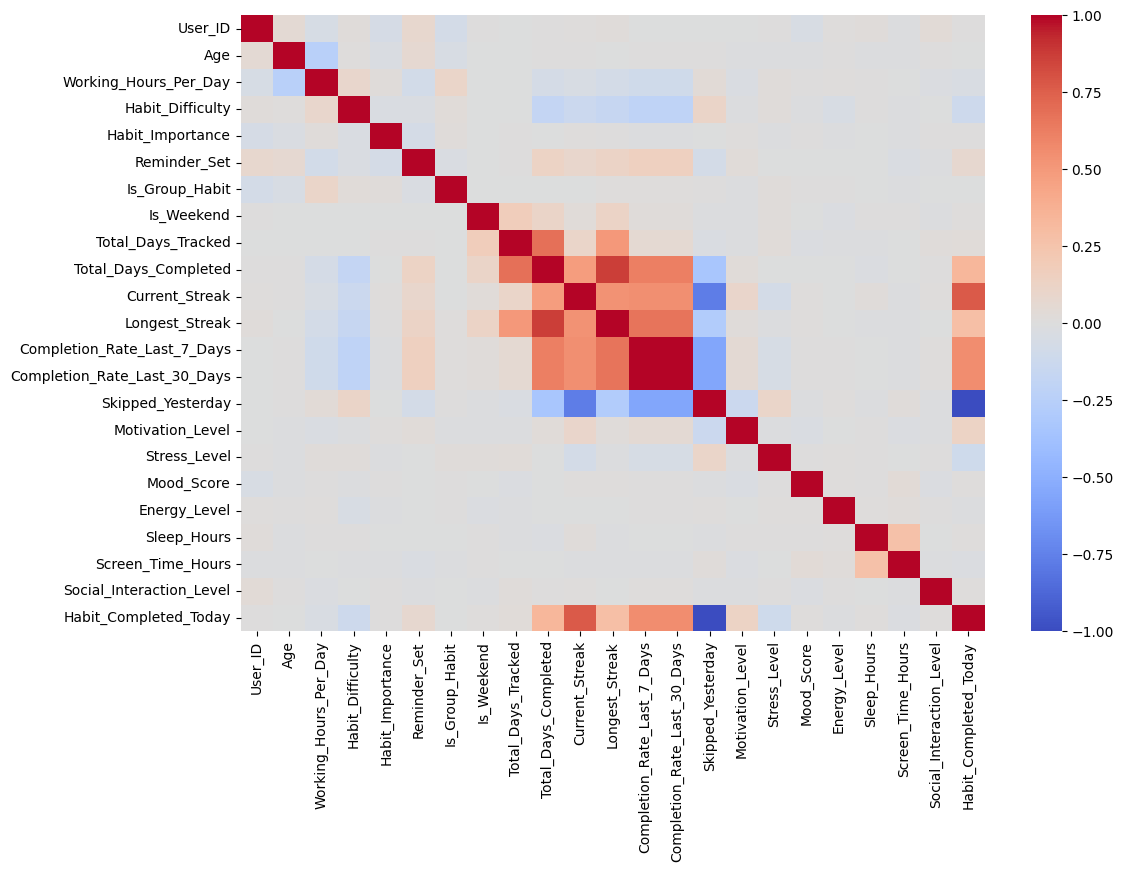

In [171]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

## Feature Engineering

In [172]:
df = df.drop(columns = ["User_ID","Total_Days_Completed","Longest_Streak","Completion_Rate_Last_7_Days","Completion_Rate_Last_30_Days"],axis=1)

In [173]:
df.head()

,Age,Gender,Occupation,Personality_Type,Working_Hours_Per_Day,Habit_Name,Habit_Category,Habit_Difficulty,Habit_Importance,Reminder_Set,Is_Group_Habit,Date,Day_of_Week,Is_Weekend,Total_Days_Tracked,Current_Streak,Skipped_Yesterday,Motivation_Level,Stress_Level,Mood_Score,Energy_Level,Sleep_Hours,Screen_Time_Hours,Social_Interaction_Level,Weather_Condition,Habit_Completed_Today
0,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-01,Monday,0,1,1,0,8,7.0,4.0,5,4.5,4.8,5,Rainy,1
1,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-02,Tuesday,0,2,0,1,5,8.0,6.0,8,5.1,3.1,5,Rainy,0
2,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-03,Wednesday,0,3,0,1,5,6.0,7.0,6,4.1,5.1,3,Sunny,0
3,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-04,Thursday,0,4,0,1,8,3.0,9.0,7,6.3,2.1,9,Sunny,0
4,24,Male,Student,Extrovert,7,Read Book,Study,5,3,1,0,2024-01-05,Friday,0,5,1,0,5,9.0,4.0,7,5.2,3.4,7,Hot,1


In [174]:
df.shape

(5000, 26)

In [175]:
df["Date"] = pd.to_datetime(df["Date"])

df["Day_Number"] = df["Date"].dt.day

df.drop("Date", axis=1, inplace=True)

In [176]:
df = df.drop([
    "Skipped_Yesterday",
    ], axis=1)

In [177]:
noise_idx = df.sample(frac=0.05).index
df.loc[noise_idx, "Habit_Completed_Today"] = 1 - df.loc[noise_idx, "Habit_Completed_Today"]

## Encoding

In [178]:
# using median for handling outliers

In [179]:
num_imputer = SimpleImputer(strategy='median')
num_cols = ['Sleep_Hours','Screen_Time_Hours']

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [180]:
# using mean to handle Nan(Null Values)

In [181]:
num_imputer = SimpleImputer(strategy='mean')
num_cols = ['Stress_Level', 'Mood_Score']

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [182]:
cat_col = ["Gender","Occupation","Personality_Type","Habit_Name","Habit_Category","Day_of_Week","Weather_Condition"]

In [183]:
df = pd.get_dummies(df,columns= cat_col,dtype=int,drop_first= True)

## Train Test Split

In [184]:
X = df.drop(columns= ["Habit_Completed_Today"])
y = df["Habit_Completed_Today"]

In [185]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature scalling

In [186]:
scaler = StandardScaler()

In [187]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Final Model 

In [188]:
xgb = XGBClassifier()

In [189]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [190]:
y_pred = xgb.predict(X_test)

In [191]:
print("XGBClassifier :")
print("accuracy_score ",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))

XGBClassifier :
accuracy_score  0.939
precision_score 0.9512820512820512
recall_score 0.8983050847457628
f1_score 0.9240348692403487


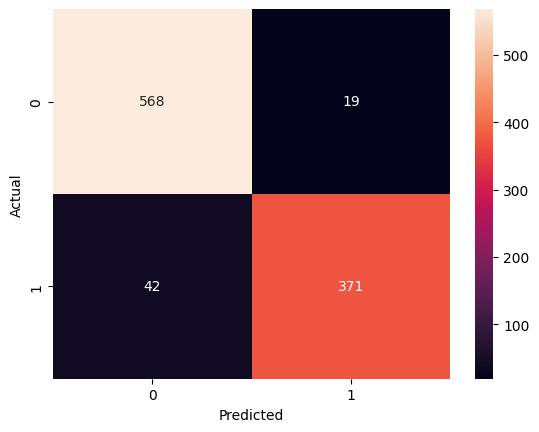

In [192]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [193]:
scores = cross_val_score(xgb, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.954 0.949 0.939 0.947 0.952]
Average Score: 0.9481999999999999
